In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prksh830/nasa-battery-master/NASA_Battery_Master.csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/prksh830/nasa-battery-master/NASA_Battery_Master.csv


In [3]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/prksh830/nasa-battery-master/NASA_Battery_Master.csv"

master_df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", master_df.shape)

master_df.head()

Dataset Loaded Successfully
Shape: (636, 23)


,Battery,Cycle,Capacity,AvgVoltage,MaxVoltage,MinVoltage,StdVoltage,AvgCurrent,StdCurrent,AvgTemp,...,Duration,SOH,RUL,DI,CFI,TSI,VHI,TGI,VSI,DTHI
0,B0005,1,1.856487,3.529829,4.191492,2.612467,0.235957,-1.818702,0.593546,32.572328,...,3690.234,100.000000,167,0.005952,0.000000,0.944386,1.000000,14.656188,0.809090,0.219002
1,B0005,2,1.846327,3.537320,4.189773,2.587209,0.234765,-1.817560,0.595180,32.725235,...,3672.344,99.452721,166,0.011905,0.005473,0.948819,1.002122,14.347450,0.809871,0.222309
2,B0005,3,1.835349,3.543737,4.188187,2.651917,0.227525,-1.816487,0.596498,32.642862,...,3651.641,98.861386,165,0.017857,0.011386,0.946431,1.003940,14.084531,0.814647,0.223809
3,B0005,4,1.835263,3.543666,4.188461,2.592948,0.232744,-1.825589,0.583462,32.514876,...,3631.563,98.856718,164,0.023810,0.011433,0.942720,1.003920,14.110061,0.811198,0.225087
4,B0005,5,1.834646,3.542343,4.188299,2.547420,0.236689,-1.826114,0.583469,32.382349,...,3629.172,98.823482,163,0.029762,0.011765,0.938878,1.003545,14.146692,0.808611,0.226334


In [4]:
print(master_df.columns.tolist())

['Battery', 'Cycle', 'Capacity', 'AvgVoltage', 'MaxVoltage', 'MinVoltage', 'StdVoltage', 'AvgCurrent', 'StdCurrent', 'AvgTemp', 'MaxTemp', 'MinTemp', 'StdTemp', 'Duration', 'SOH', 'RUL', 'DI', 'CFI', 'TSI', 'VHI', 'TGI', 'VSI', 'DTHI']


In [5]:
print(master_df.shape)

(636, 23)


In [6]:
print(master_df.columns.tolist())

['Battery', 'Cycle', 'Capacity', 'AvgVoltage', 'MaxVoltage', 'MinVoltage', 'StdVoltage', 'AvgCurrent', 'StdCurrent', 'AvgTemp', 'MaxTemp', 'MinTemp', 'StdTemp', 'Duration', 'SOH', 'RUL', 'DI', 'CFI', 'TSI', 'VHI', 'TGI', 'VSI', 'DTHI']


In [7]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import shap

RESULT_DIR = "/kaggle/working/DTEC_Net_SCI_Final"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Environment Ready")

Environment Ready


In [8]:
RESULT_DIR = "/kaggle/working/DTEC_Net_SCI_Final"

import os

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Result Folder Created")

Result Folder Created


In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

plt.rcParams['figure.dpi'] = 150

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


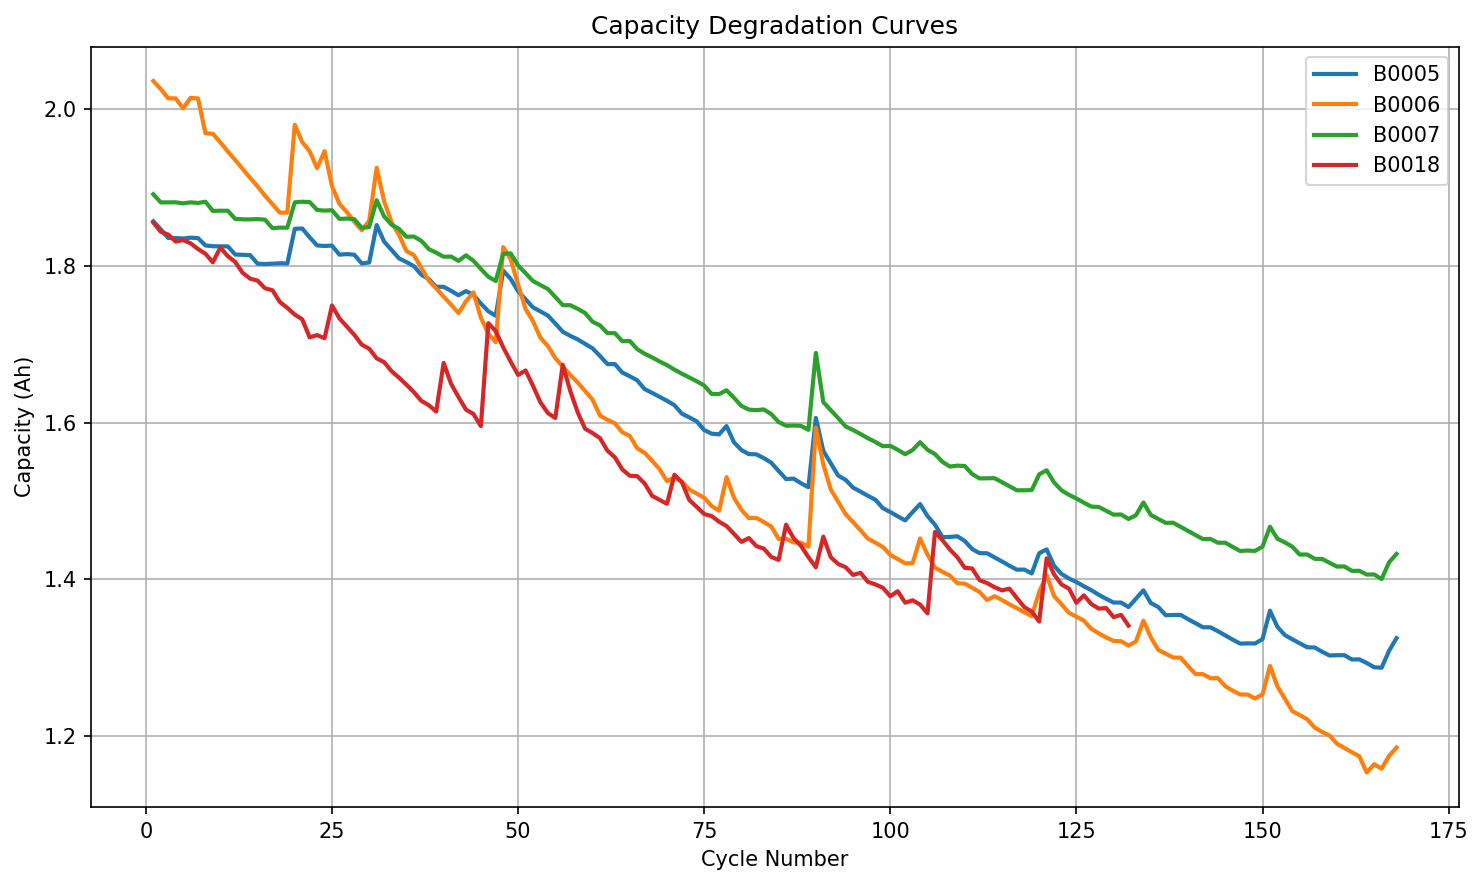

In [10]:
plt.figure(figsize=(10,6))

for battery in master_df['Battery'].unique():

    subset = master_df[
        master_df['Battery']==battery
    ]

    plt.plot(
        subset['Cycle'],
        subset['Capacity'],
        linewidth=2,
        label=battery
    )

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_01_Capacity_Degradation.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

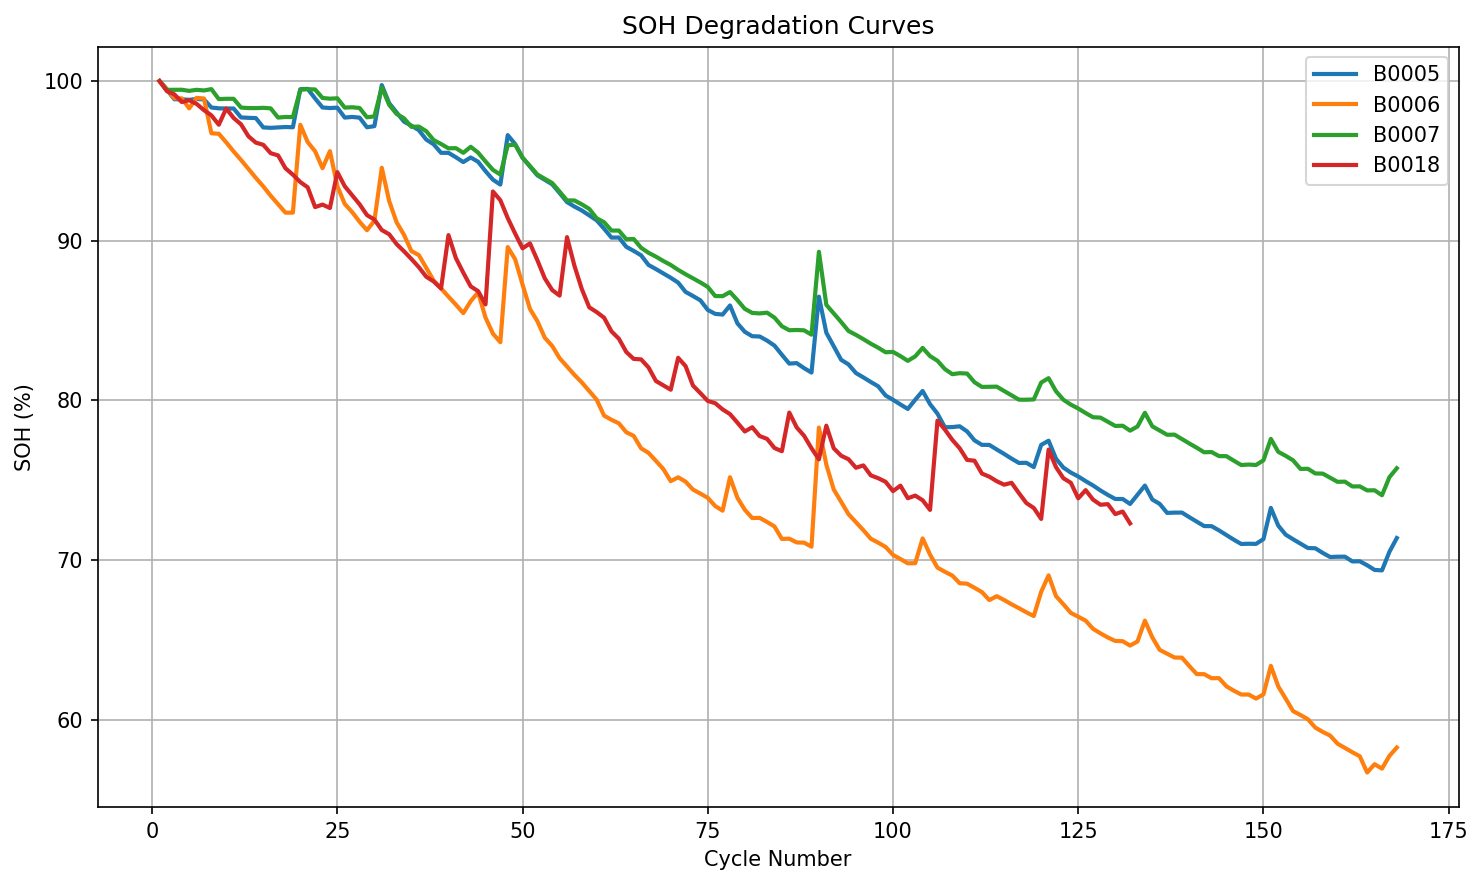

In [11]:
plt.figure(figsize=(10,6))

for battery in master_df['Battery'].unique():

    subset = master_df[
        master_df['Battery']==battery
    ]

    plt.plot(
        subset['Cycle'],
        subset['SOH'],
        linewidth=2,
        label=battery
    )

plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("SOH Degradation Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_02_SOH_Degradation.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

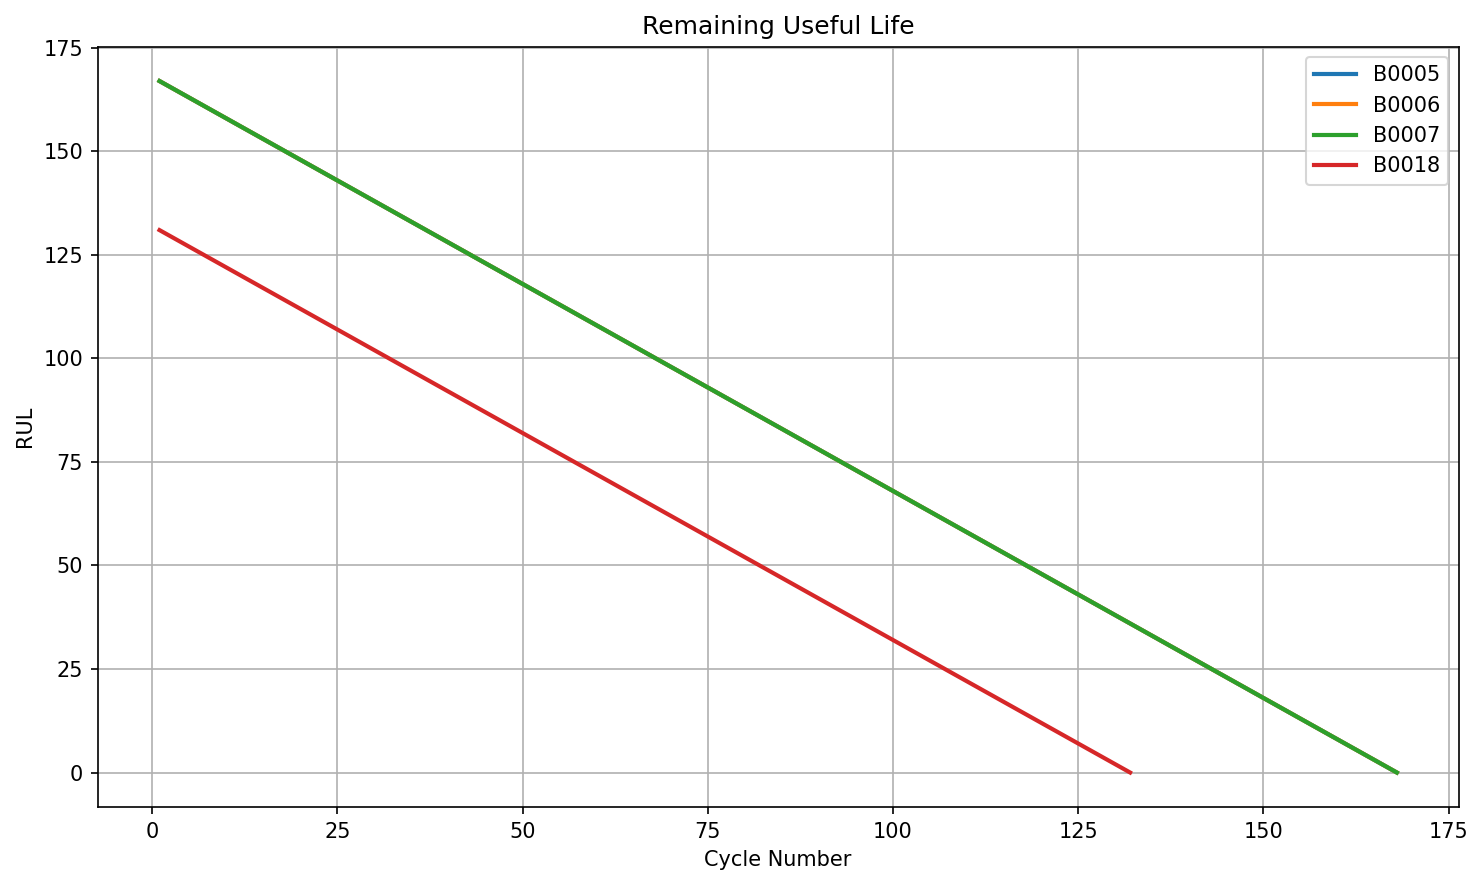

In [12]:
plt.figure(figsize=(10,6))

for battery in master_df['Battery'].unique():

    subset = master_df[
        master_df['Battery']==battery
    ]

    plt.plot(
        subset['Cycle'],
        subset['RUL'],
        linewidth=2,
        label=battery
    )

plt.xlabel("Cycle Number")
plt.ylabel("RUL")
plt.title("Remaining Useful Life")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_03_RUL_Evolution.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

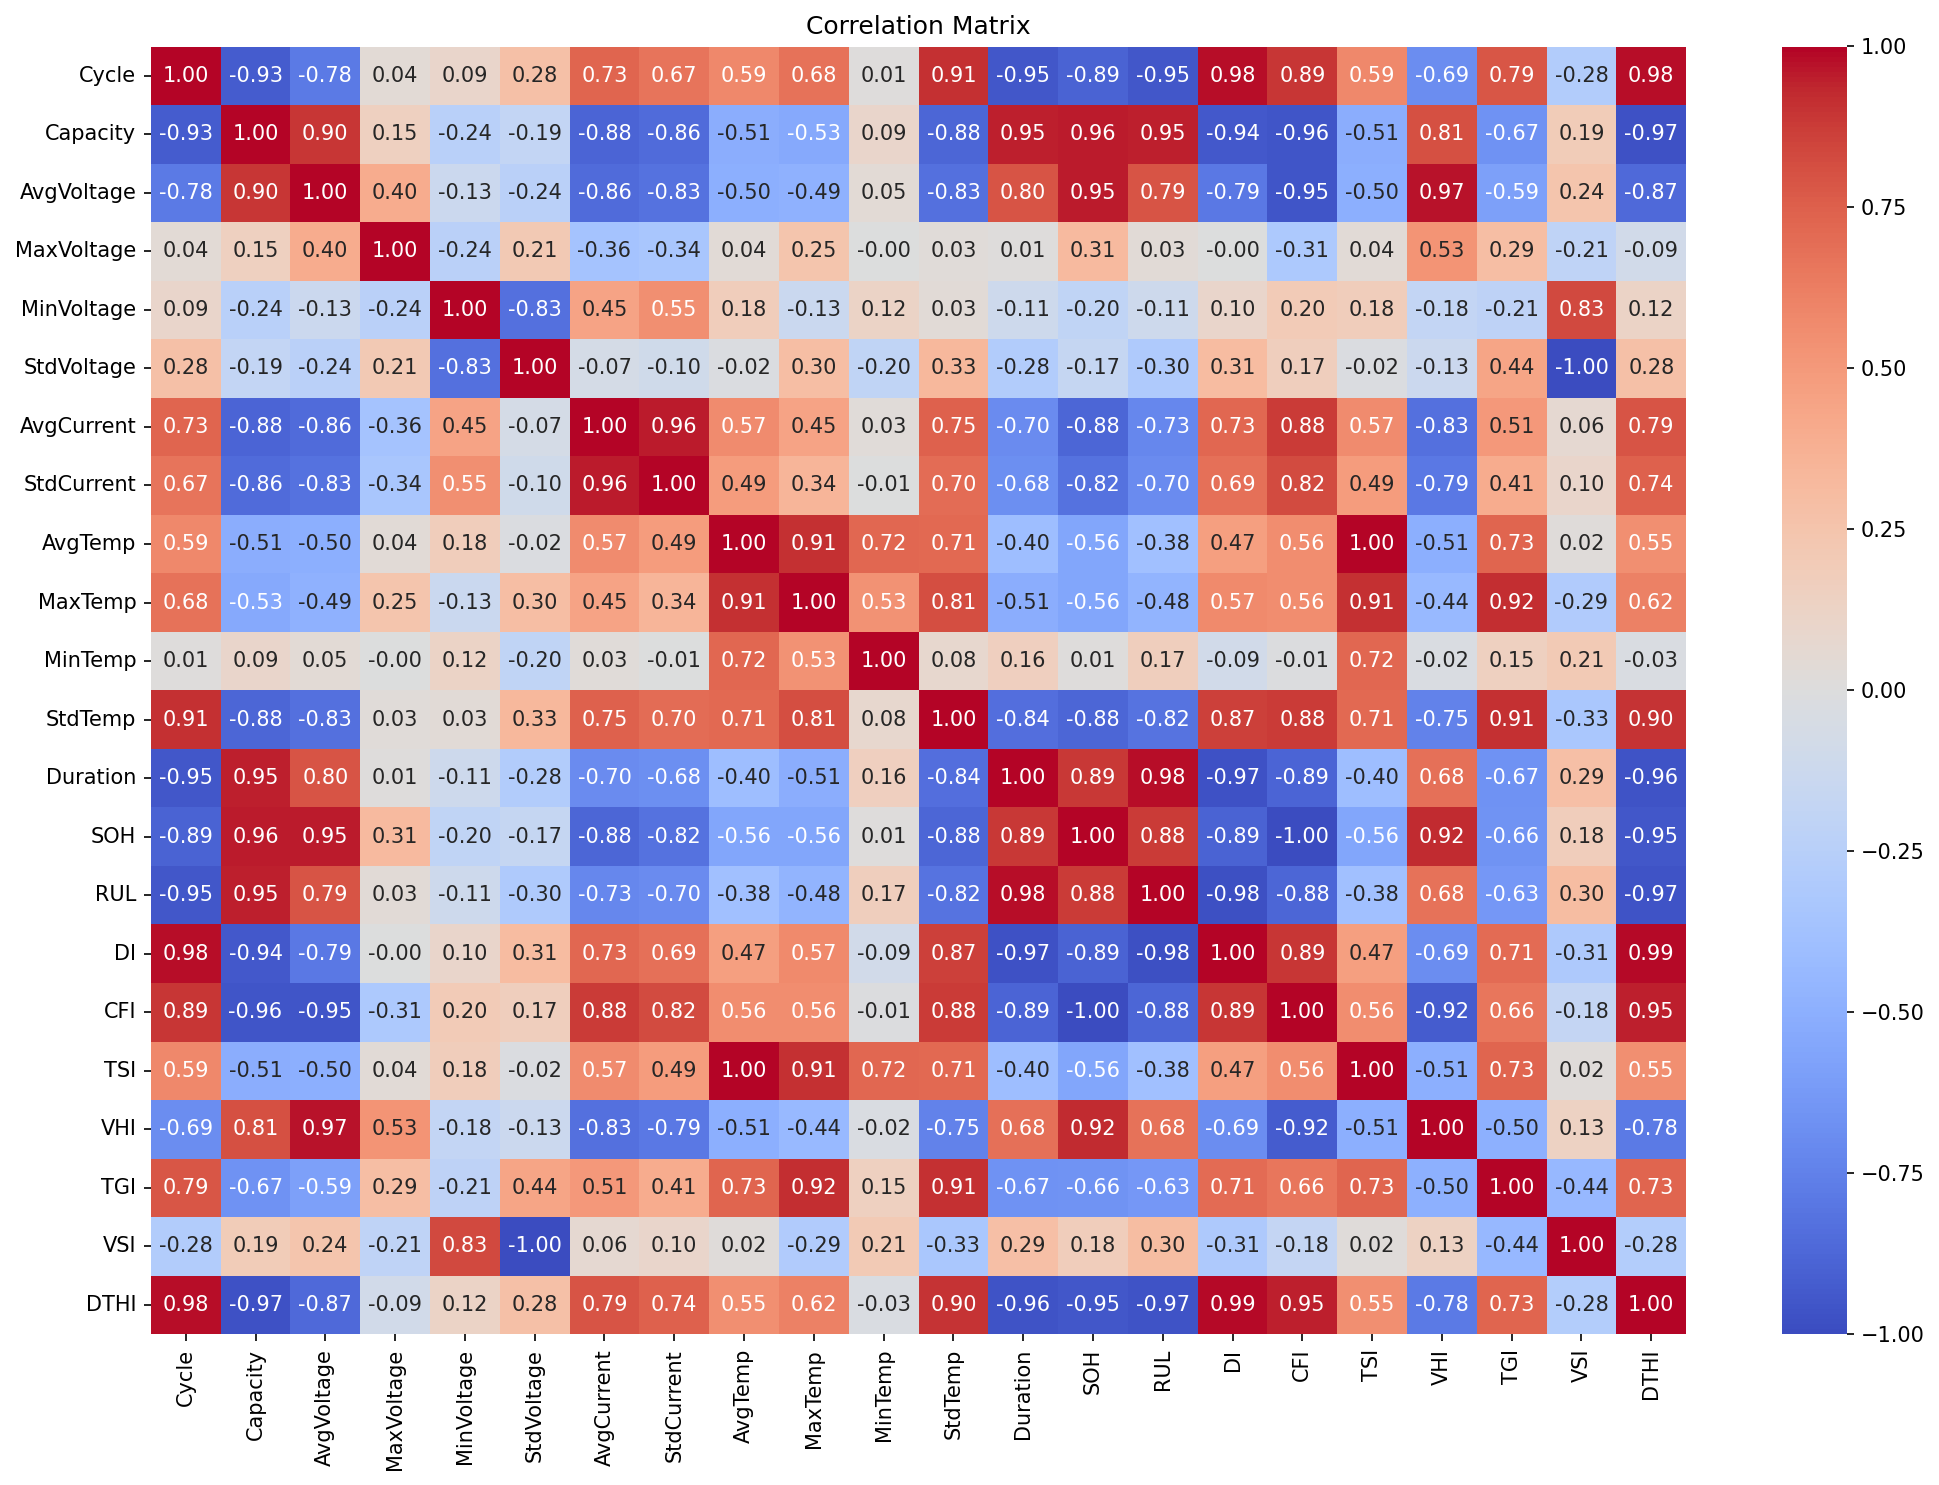

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(

    master_df.corr(
        numeric_only=True
    ),

    annot=True,

    fmt=".2f",

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_04_Correlation_Matrix.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

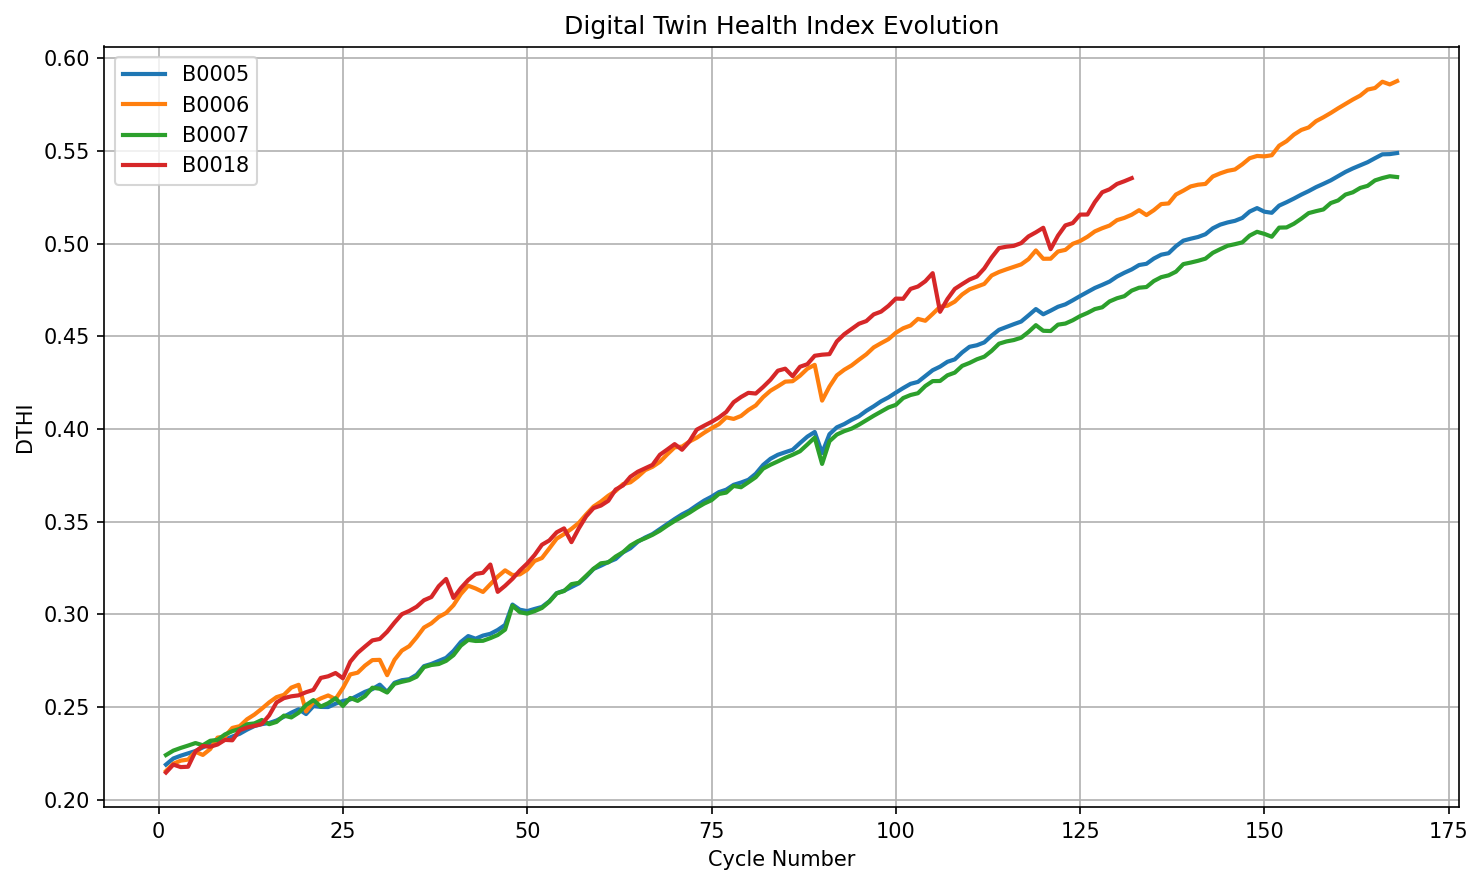

In [14]:
plt.figure(figsize=(10,6))

for battery in master_df['Battery'].unique():

    subset = master_df[
        master_df['Battery']==battery
    ]

    plt.plot(
        subset['Cycle'],
        subset['DTHI'],
        linewidth=2,
        label=battery
    )

plt.xlabel("Cycle Number")
plt.ylabel("DTHI")
plt.title("Digital Twin Health Index Evolution")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_05_DTHI_Evolution.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

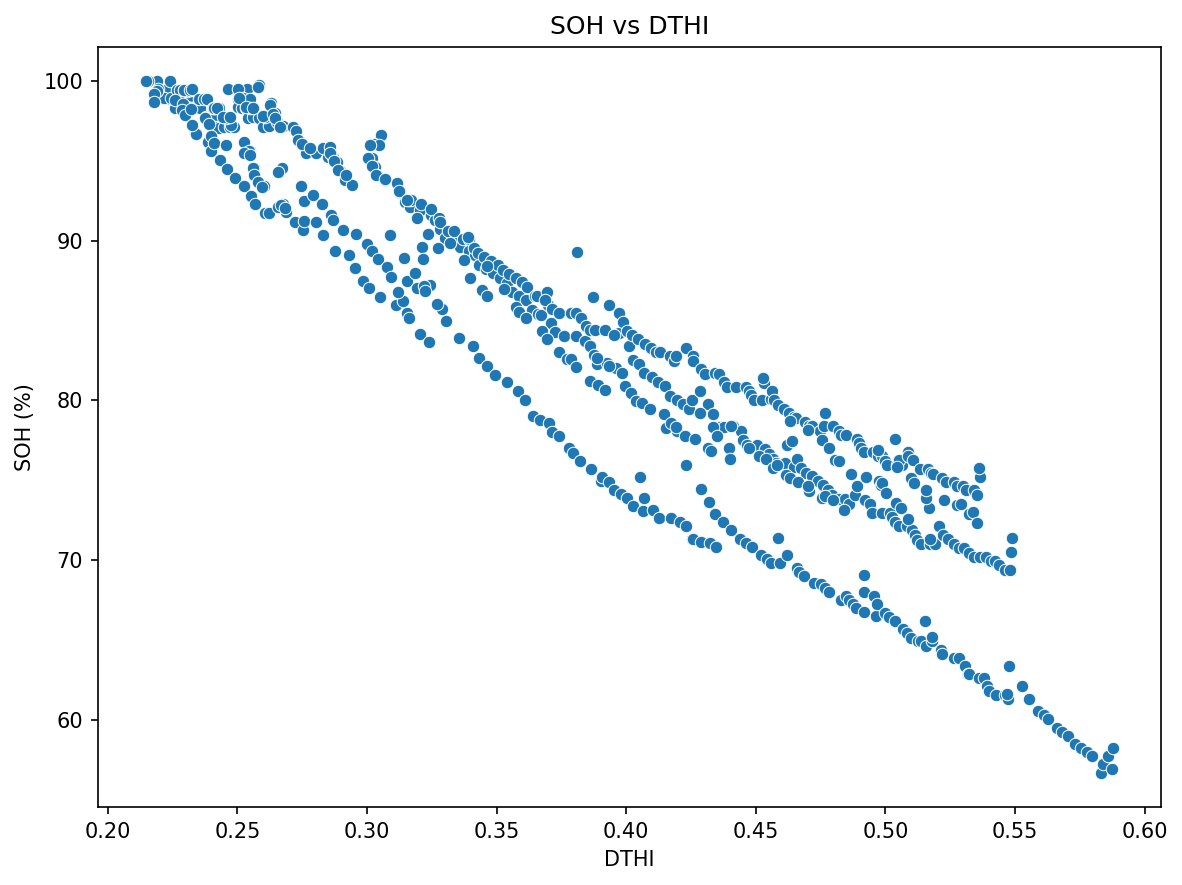

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=master_df,

    x='DTHI',

    y='SOH'

)

plt.xlabel("DTHI")
plt.ylabel("SOH (%)")

plt.title("SOH vs DTHI")

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_07_SOH_vs_DTHI.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

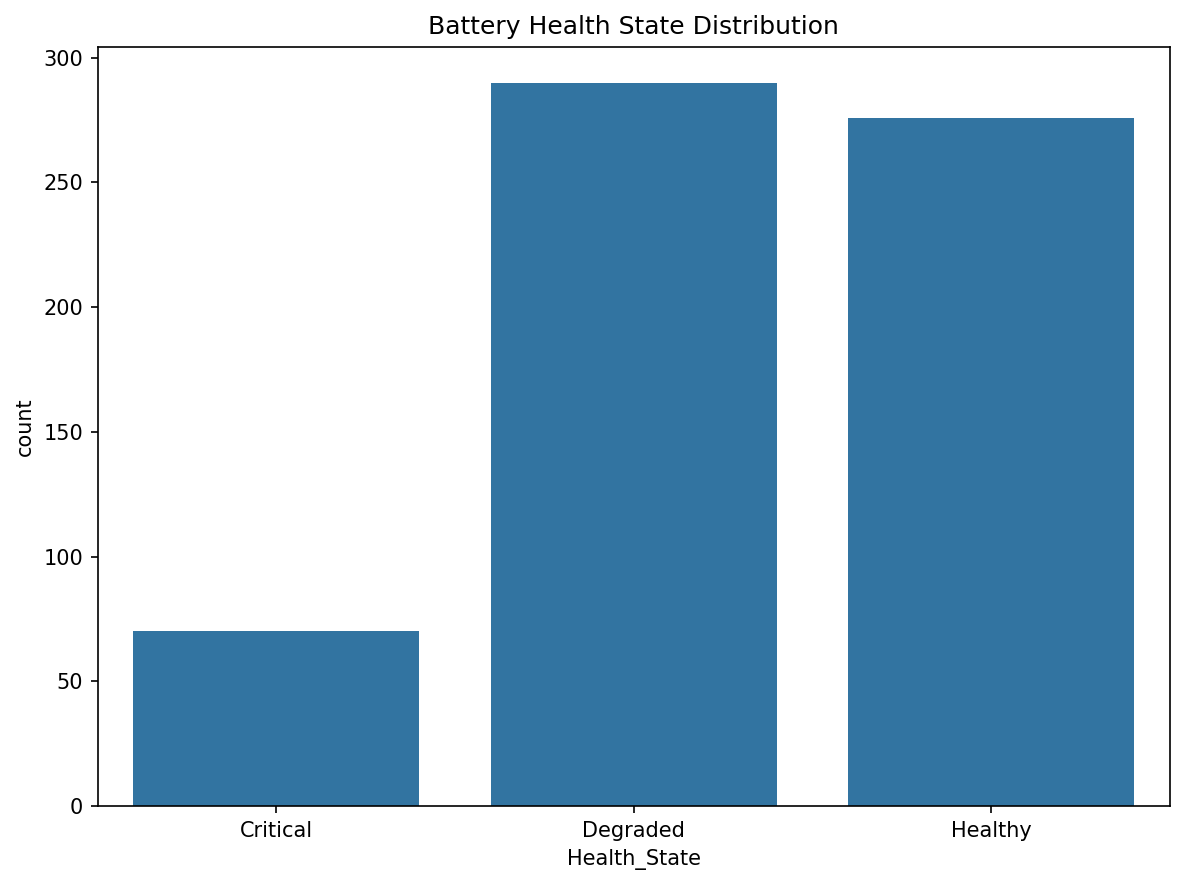

In [16]:
master_df['Health_State'] = pd.cut(

    master_df['SOH'],

    bins=[0,70,85,100],

    labels=[

        'Critical',

        'Degraded',

        'Healthy'

    ]

)

plt.figure(figsize=(8,6))

sns.countplot(
    x='Health_State',
    data=master_df
)

plt.title(
    "Battery Health State Distribution"
)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_10_Health_State_Distribution.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

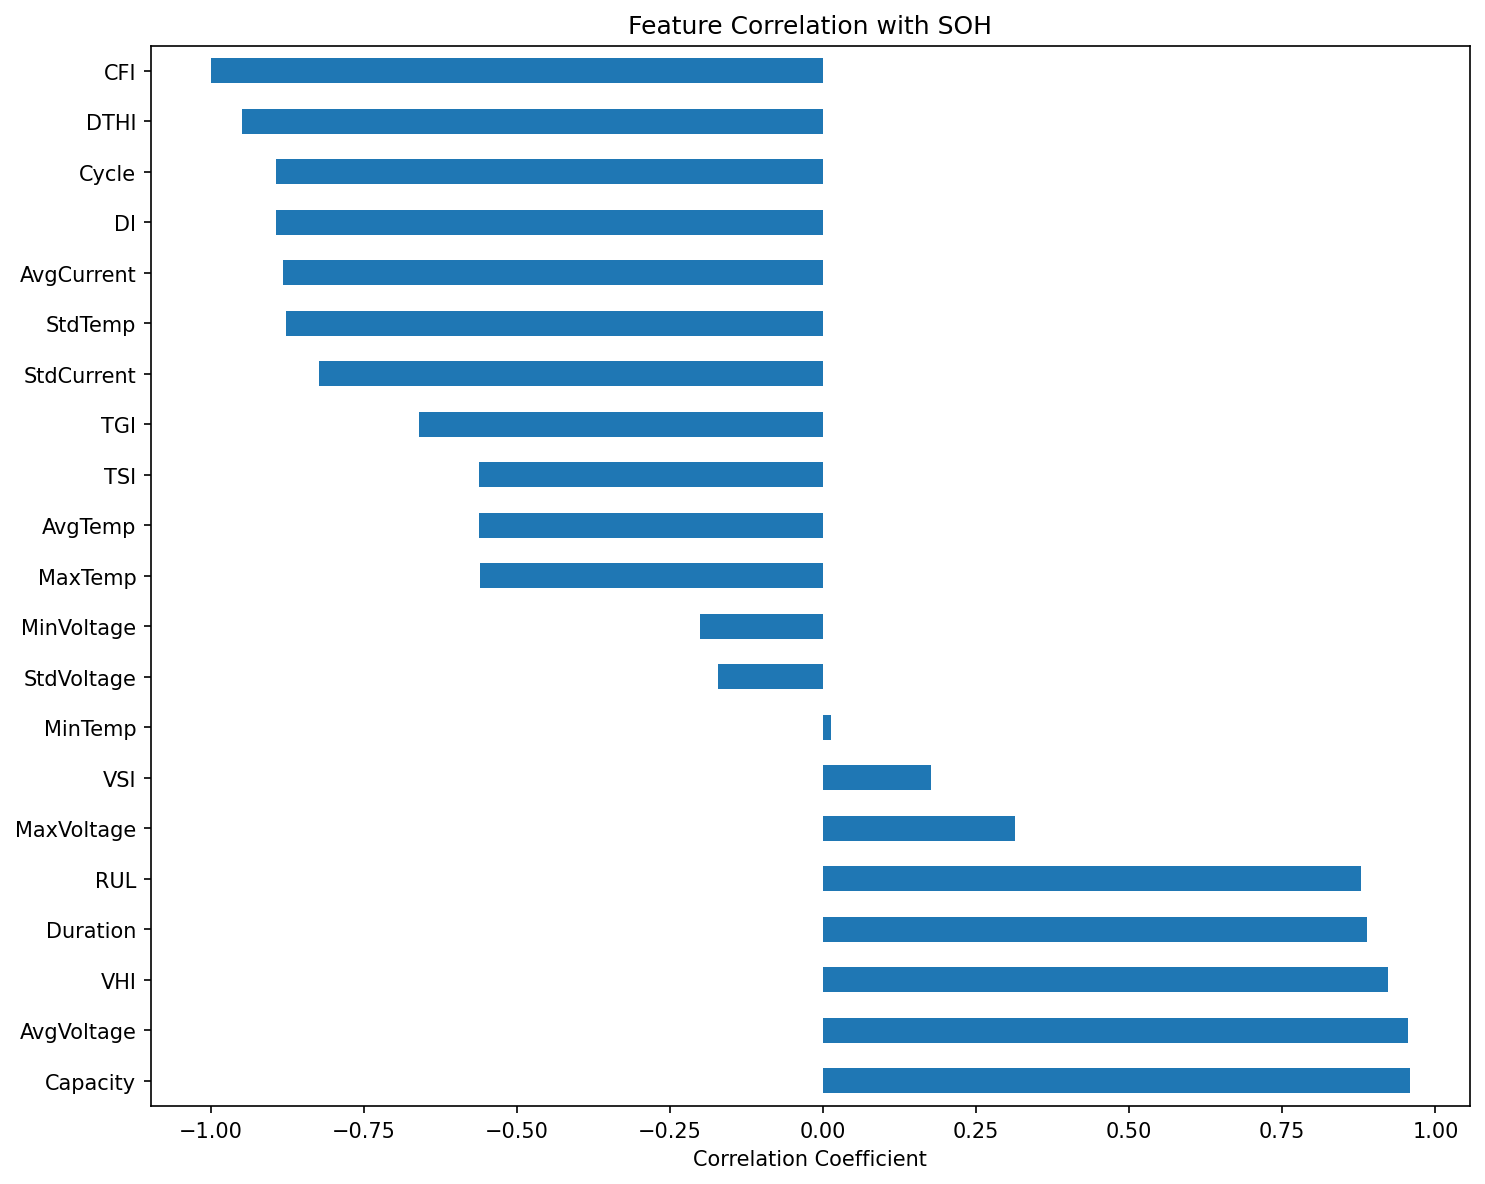

In [17]:
corr_soh = (

    master_df.corr(
        numeric_only=True
    )['SOH']

    .sort_values(
        ascending=False
    )

)

corr_soh.to_csv(
    f"{RESULT_DIR}/Feature_Correlation_with_SOH.csv"
)

plt.figure(figsize=(10,8))

corr_soh.drop(
    'SOH'
).plot(
    kind='barh'
)

plt.title(
    "Feature Correlation with SOH"
)

plt.xlabel(
    "Correlation Coefficient"
)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/Figure_11_Feature_Correlation_SOH.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

In [18]:
import os

for file in sorted(
    os.listdir(RESULT_DIR)
):
    print(file)

Feature_Correlation_with_SOH.csv
Figure_01_Capacity_Degradation.tiff
Figure_02_SOH_Degradation.tiff
Figure_03_RUL_Evolution.tiff
Figure_04_Correlation_Matrix.tiff
Figure_05_DTHI_Evolution.tiff
Figure_07_SOH_vs_DTHI.tiff
Figure_10_Health_State_Distribution.tiff
Figure_11_Feature_Correlation_SOH.tiff


In [19]:
corr_soh.head(15)

SOH           1.000000
Capacity      0.958613
AvgVoltage    0.954996
VHI           0.922875
Duration      0.888543
RUL           0.877959
MaxVoltage    0.312725
VSI           0.175822
MinTemp       0.012441
StdVoltage   -0.171377
MinVoltage   -0.200256
MaxTemp      -0.559740
AvgTemp      -0.561959
TSI          -0.561959
TGI          -0.659147
Name: SOH, dtype: float64

In [20]:
print(master_df[['DI','CFI']].dtypes)

print(master_df[['DI','CFI']].describe())

print(master_df[['DI','CFI']].head())

DI     float64
CFI    float64
dtype: object
               DI         CFI
count  636.000000  636.000000
mean     0.503145    0.171518
std      0.288897    0.109306
min      0.005952    0.000000
25%      0.254464    0.074738
50%      0.502976    0.176822
75%      0.751488    0.251933
max      1.000000    0.433107
         DI       CFI
0  0.005952  0.000000
1  0.011905  0.005473
2  0.017857  0.011386
3  0.023810  0.011433
4  0.029762  0.011765


In [21]:
corr_soh = (
    master_df.corr(
        numeric_only=True
    )['SOH']
    .sort_values(
        ascending=False
    )
)

print(corr_soh)

SOH           1.000000
Capacity      0.958613
AvgVoltage    0.954996
VHI           0.922875
Duration      0.888543
RUL           0.877959
MaxVoltage    0.312725
VSI           0.175822
MinTemp       0.012441
StdVoltage   -0.171377
MinVoltage   -0.200256
MaxTemp      -0.559740
AvgTemp      -0.561959
TSI          -0.561959
TGI          -0.659147
StdCurrent   -0.823761
StdTemp      -0.877106
AvgCurrent   -0.881931
DI           -0.893390
Cycle        -0.894295
DTHI         -0.949306
CFI          -1.000000
Name: SOH, dtype: float64


In [22]:
candidate_features = [

    'AvgVoltage',
    'MaxVoltage',

    'AvgCurrent',

    'AvgTemp',

    'Duration',

    'Cycle',

    'DI',
    'TSI',
    'VHI',
    'TGI',
    'VSI'
]

corr_matrix = master_df[
    candidate_features
].corr()

print(corr_matrix)

            AvgVoltage  MaxVoltage  AvgCurrent   AvgTemp  Duration     Cycle  \
AvgVoltage    1.000000    0.398596   -0.857811 -0.504398  0.796535 -0.783624   
MaxVoltage    0.398596    1.000000   -0.363870  0.035092  0.007987  0.039567   
AvgCurrent   -0.857811   -0.363870    1.000000  0.566500 -0.702162  0.726819   
AvgTemp      -0.504398    0.035092    0.566500  1.000000 -0.402986  0.585388   
Duration      0.796535    0.007987   -0.702162 -0.402986  1.000000 -0.947097   
Cycle        -0.783624    0.039567    0.726819  0.585388 -0.947097  1.000000   
DI           -0.794286   -0.003271    0.725201  0.473623 -0.974746  0.983678   
TSI          -0.504398    0.035092    0.566500  1.000000 -0.402986  0.585388   
VHI           0.974891    0.528972   -0.832849 -0.507083  0.684053 -0.688995   
TGI          -0.590027    0.292871    0.507396  0.727238 -0.670890  0.785483   
VSI           0.242795   -0.208364    0.062974  0.020131  0.287267 -0.281320   

                  DI       TSI       VH

In [23]:
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [24]:
train_df = master_df[
    master_df['Battery'].isin(
        ['B0005','B0006','B0007']
    )
]

test_df = master_df[
    master_df['Battery']=='B0018'
]

print(train_df.shape)
print(test_df.shape)

(504, 24)
(132, 24)


In [25]:
def evaluate_feature_set(

    feature_set,

    model_name

):

    X_train = train_df[
        feature_set
    ]

    y_train = train_df[
        'SOH'
    ]

    X_test = test_df[
        feature_set
    ]

    y_test = test_df[
        'SOH'
    ]

    model = CatBoostRegressor(

        iterations=300,

        learning_rate=0.05,

        verbose=False,

        random_state=42

    )

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    mape = np.mean(
        np.abs(
            (y_test-preds)
            /
            y_test
        )
    ) * 100

    r2 = r2_score(
        y_test,
        preds
    )

    return [

        model_name,

        len(feature_set),

        mae,

        rmse,

        mape,

        r2

    ]

In [26]:
FULL_FEATURES = [

    'AvgVoltage',
    'MaxVoltage',

    'AvgCurrent',

    'AvgTemp',

    'Duration',

    'Cycle',

    'DI',
    'TSI',
    'VHI',
    'TGI',
    'VSI'
]

REDUCED_FEATURES = [

    'AvgVoltage',

    'MaxVoltage',

    'AvgCurrent',

    'AvgTemp',

    'Duration',

    'VHI',

    'TGI',

    'VSI'
]

In [27]:
results_compare = pd.DataFrame(

    [

        evaluate_feature_set(
            FULL_FEATURES,
            'Full_DTEC'
        ),

        evaluate_feature_set(
            REDUCED_FEATURES,
            'Reduced_DTEC'
        )

    ],

    columns=[

        'Model',

        'Num_Features',

        'MAE',

        'RMSE',

        'MAPE',

        'R2'
    ]
)

results_compare

,Model,Num_Features,MAE,RMSE,MAPE,R2
0,Full_DTEC,11,1.056841,1.352716,1.221058,0.973552
1,Reduced_DTEC,8,1.342473,1.706551,1.597628,0.957907


In [28]:
results_compare.to_csv(

    f"{RESULT_DIR}/Table_Feature_Set_Comparison.csv",

    index=False

)

In [29]:
DTEC_FEATURES = [

    'AvgVoltage',
    'MaxVoltage',

    'AvgCurrent',

    'AvgTemp',

    'Duration',

    'Cycle',

    'DI',
    'TSI',
    'VHI',
    'TGI',
    'VSI'
]

In [30]:
train_df = master_df[
    master_df['Battery'].isin(
        ['B0005','B0006','B0007']
    )
]

test_df = master_df[
    master_df['Battery']=='B0018'
]

X_train = train_df[DTEC_FEATURES]
y_train = train_df['SOH']

X_test = test_df[DTEC_FEATURES]
y_test = test_df['SOH']

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(
    model_name,
    y_true,
    preds
):

    mae = mean_absolute_error(
        y_true,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            preds
        )
    )

    mape = np.mean(
        np.abs(
            (y_true-preds)
            /
            y_true
        )
    )*100

    r2 = r2_score(
        y_true,
        preds
    )

    return [

        model_name,
        mae,
        rmse,
        mape,
        r2
    ]

In [32]:
from sklearn.ensemble import RandomForestRegressor

dt_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

dt_rf.fit(
    X_train,
    y_train
)

pred_dt_rf = dt_rf.predict(
    X_test
)

In [33]:
from xgboost import XGBRegressor

dt_xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

dt_xgb.fit(
    X_train,
    y_train
)

pred_dt_xgb = dt_xgb.predict(
    X_test
)

In [34]:
from lightgbm import LGBMRegressor

dt_lgbm = LGBMRegressor(

    n_estimators=300,

    learning_rate=0.05,

    random_state=42

)

dt_lgbm.fit(
    X_train,
    y_train
)

pred_dt_lgbm = dt_lgbm.predict(
    X_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 504, number of used features: 11
[LightGBM] [Info] Start training from score 82.553600
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [35]:
from catboost import CatBoostRegressor

dtec = CatBoostRegressor(

    iterations=300,

    learning_rate=0.05,

    verbose=False,

    random_state=42

)

dtec.fit(
    X_train,
    y_train
)

pred_dtec = dtec.predict(
    X_test
)

In [36]:
dt_results = pd.DataFrame(

    [

        evaluate_model(
            'DT-RF',
            y_test,
            pred_dt_rf
        ),

        evaluate_model(
            'DT-XGB',
            y_test,
            pred_dt_xgb
        ),

        evaluate_model(
            'DT-LGBM',
            y_test,
            pred_dt_lgbm
        ),

        evaluate_model(
            'DTEC-Net',
            y_test,
            pred_dtec
        )

    ],

    columns=[

        'Model',

        'MAE',

        'RMSE',

        'MAPE',

        'R2'

    ]

)

dt_results

,Model,MAE,RMSE,MAPE,R2
0,DT-RF,1.580676,1.945585,1.825143,0.945289
1,DT-XGB,1.646075,1.998515,1.933615,0.942271
2,DT-LGBM,1.263925,1.683299,1.452269,0.959046
3,DTEC-Net,1.056841,1.352716,1.221058,0.973552


In [37]:
dt_results.to_csv(

    f"{RESULT_DIR}/Table_10_DT_Model_Comparison.csv",

    index=False

)

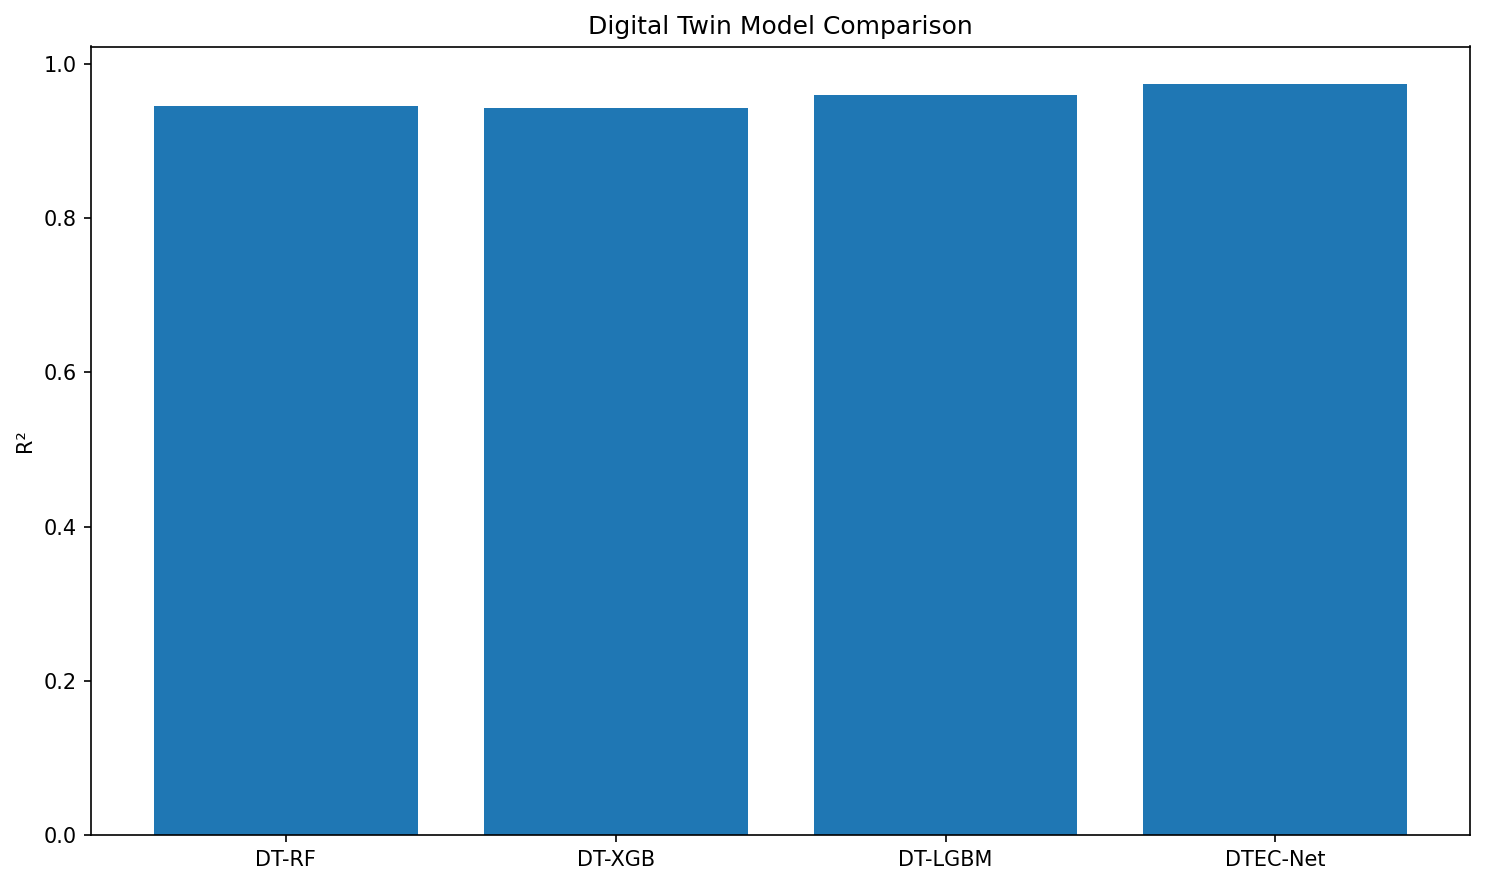

In [38]:
plt.figure(figsize=(10,6))

plt.bar(

    dt_results['Model'],

    dt_results['R2']

)

plt.ylabel("R²")

plt.title(
    "Digital Twin Model Comparison"
)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_29_DT_Model_Comparison.tiff",

    dpi=600,

    format='tiff'

)

plt.show()

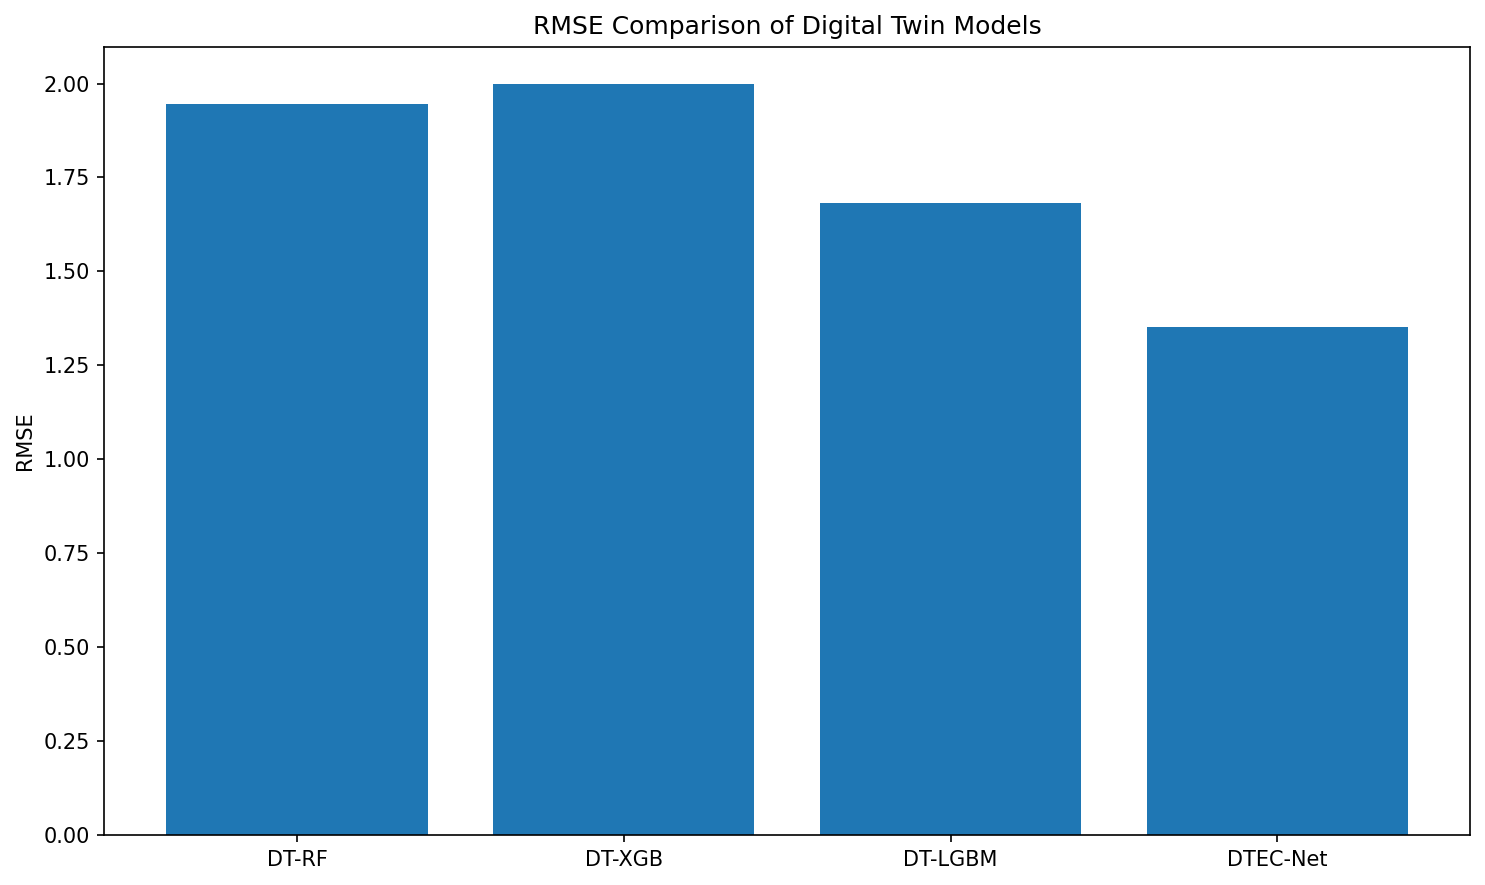

In [39]:
plt.figure(figsize=(10,6))

plt.bar(

    dt_results['Model'],

    dt_results['RMSE']

)

plt.ylabel("RMSE")

plt.title(
    "RMSE Comparison of Digital Twin Models"
)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_30_DT_Model_RMSE.tiff",

    dpi=600,

    format='tiff'

)

plt.show()

In [40]:
dt_results

,Model,MAE,RMSE,MAPE,R2
0,DT-RF,1.580676,1.945585,1.825143,0.945289
1,DT-XGB,1.646075,1.998515,1.933615,0.942271
2,DT-LGBM,1.263925,1.683299,1.452269,0.959046
3,DTEC-Net,1.056841,1.352716,1.221058,0.973552


In [41]:
feature_importance = pd.DataFrame({

    'Feature': DTEC_FEATURES,

    'Importance': dtec.feature_importances_

})

feature_importance = (

    feature_importance

    .sort_values(
        'Importance',
        ascending=False
    )

)

feature_importance

,Feature,Importance
0,AvgVoltage,19.769462
6,DI,14.292333
8,VHI,14.150699
2,AvgCurrent,11.993801
4,Duration,10.865806
1,MaxVoltage,10.527405
5,Cycle,10.161141
10,VSI,2.606914
7,TSI,2.350288
3,AvgTemp,1.650192


In [42]:
feature_importance.to_csv(

    f"{RESULT_DIR}/Table_05_Feature_Importance.csv",

    index=False

)

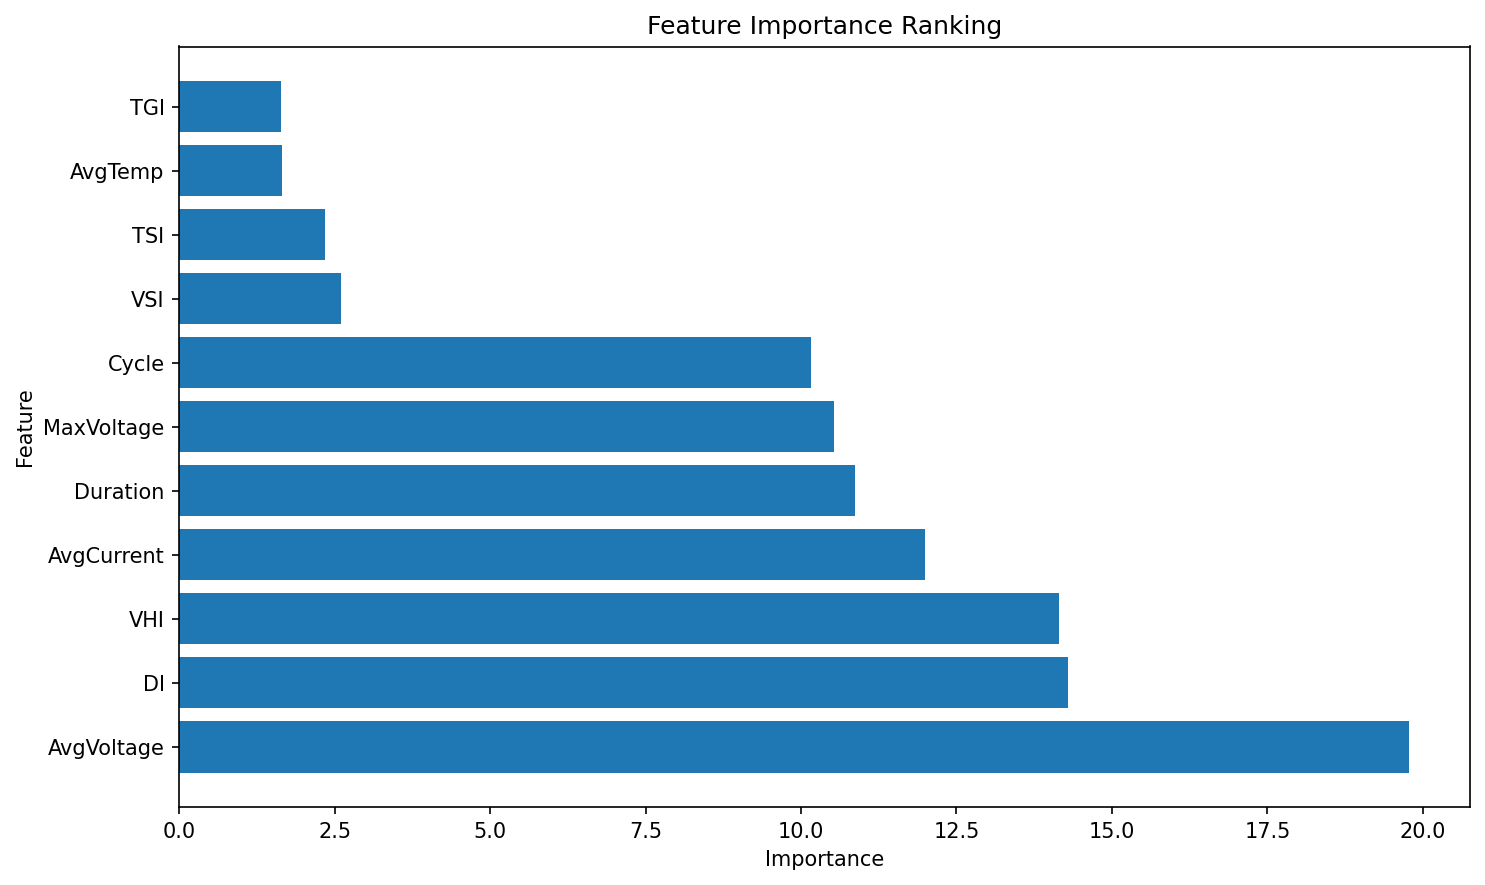

In [43]:
plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'],

    feature_importance['Importance']

)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Feature Importance Ranking"
)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_21_Feature_Importance.tiff",

    dpi=600,

    format='tiff'

)

plt.show()

In [44]:
import shap

explainer = shap.TreeExplainer(
    dtec
)

shap_values = explainer.shap_values(
    X_test
)

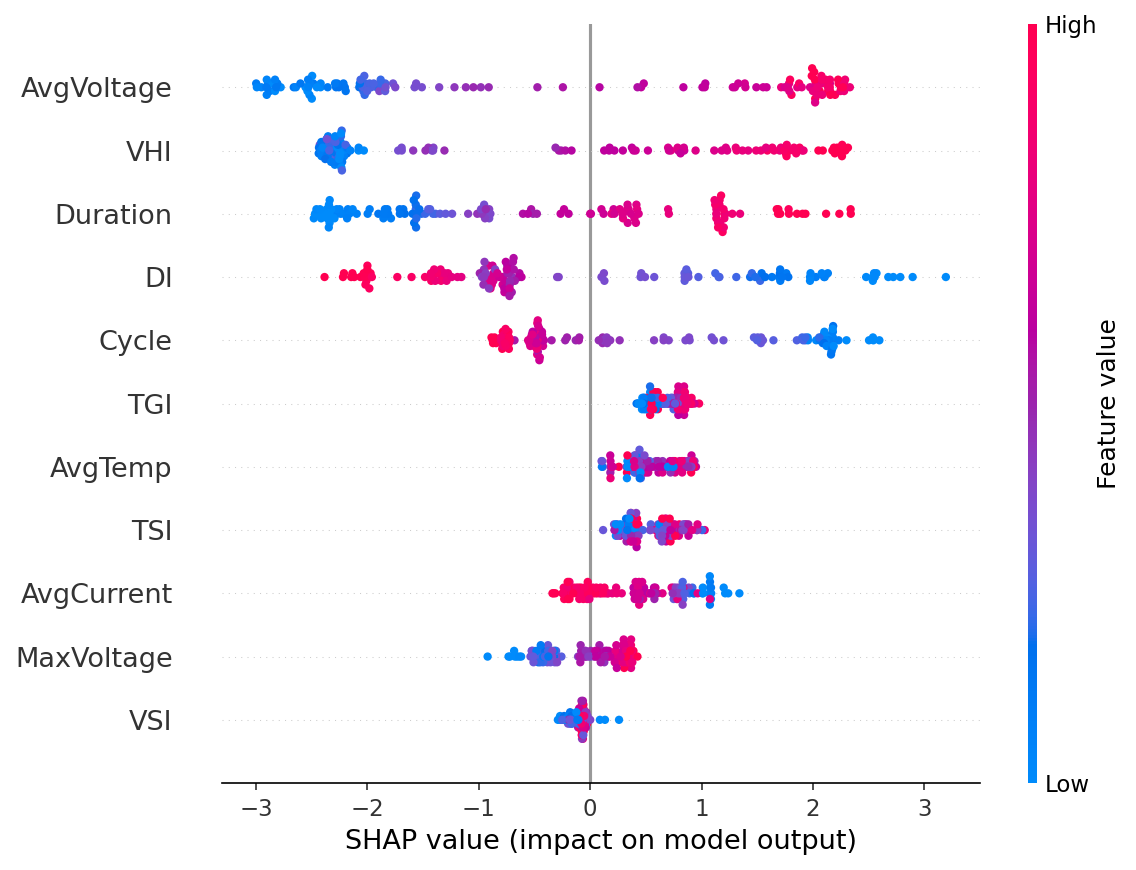

In [45]:
shap.summary_plot(

    shap_values,

    X_test,

    show=False

)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_22_SHAP_Summary.tiff",

    dpi=600,

    format='tiff',

    bbox_inches='tight'

)

plt.show()

In [46]:
top_feature = (

    feature_importance

    .iloc[0]['Feature']

)

print(
    "Top Feature:",
    top_feature
)

Top Feature: AvgVoltage


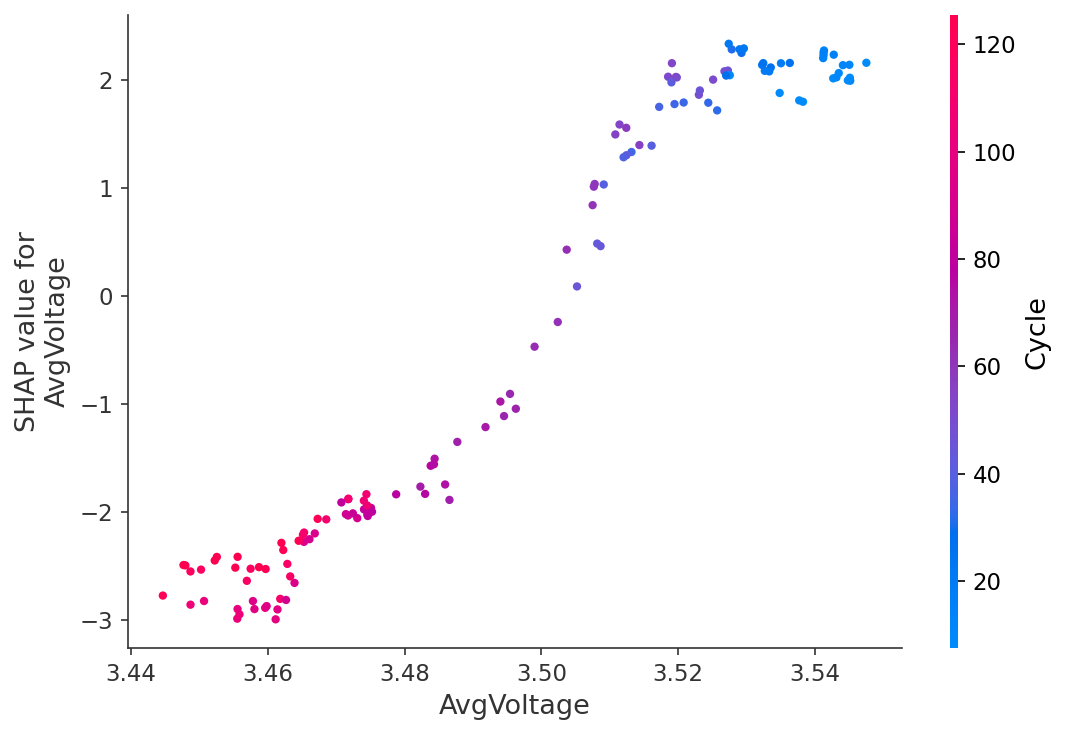

In [47]:
shap.dependence_plot(

    top_feature,

    shap_values,

    X_test,

    show=False

)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_23_SHAP_Dependence.tiff",

    dpi=600,

    format='tiff',

    bbox_inches='tight'

)

plt.show()

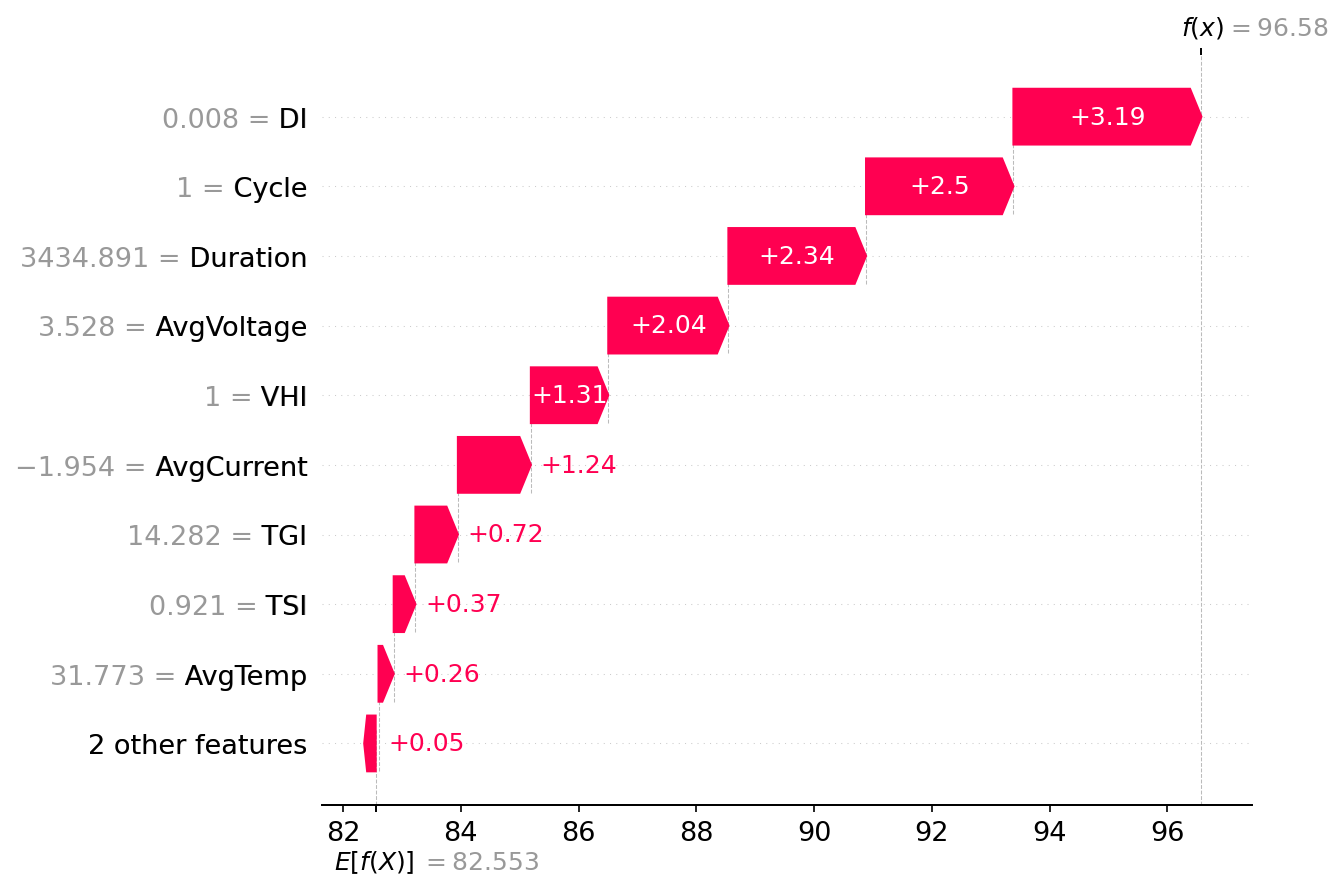

In [48]:
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[0],

        base_values=explainer.expected_value,

        data=X_test.iloc[0],

        feature_names=X_test.columns

    ),

    show=False

)

plt.savefig(

    f"{RESULT_DIR}/Figure_24_SHAP_Waterfall.tiff",

    dpi=600,

    format='tiff',

    bbox_inches='tight'

)

plt.show()

In [49]:
ablation_results = pd.DataFrame({

'Configuration':[

'Physical Features',

'Physical + DT Components',

'Physical + DT Components + DTHI'

],

'MAE':[

1.800986,

1.056841,

1.093303

],

'RMSE':[

2.185447,

1.352716,

1.411444

],

'MAPE':[

2.085043,

1.221058,

1.263095

],

'R2':[

0.930967,

0.973552,

0.971206

]

})

ablation_results

,Configuration,MAE,RMSE,MAPE,R2
0,Physical Features,1.800986,2.185447,2.085043,0.930967
1,Physical + DT Components,1.056841,1.352716,1.221058,0.973552
2,Physical + DT Components + DTHI,1.093303,1.411444,1.263095,0.971206


In [50]:
ablation_results.to_csv(

    f"{RESULT_DIR}/Table_06_Ablation_Study.csv",

    index=False

)

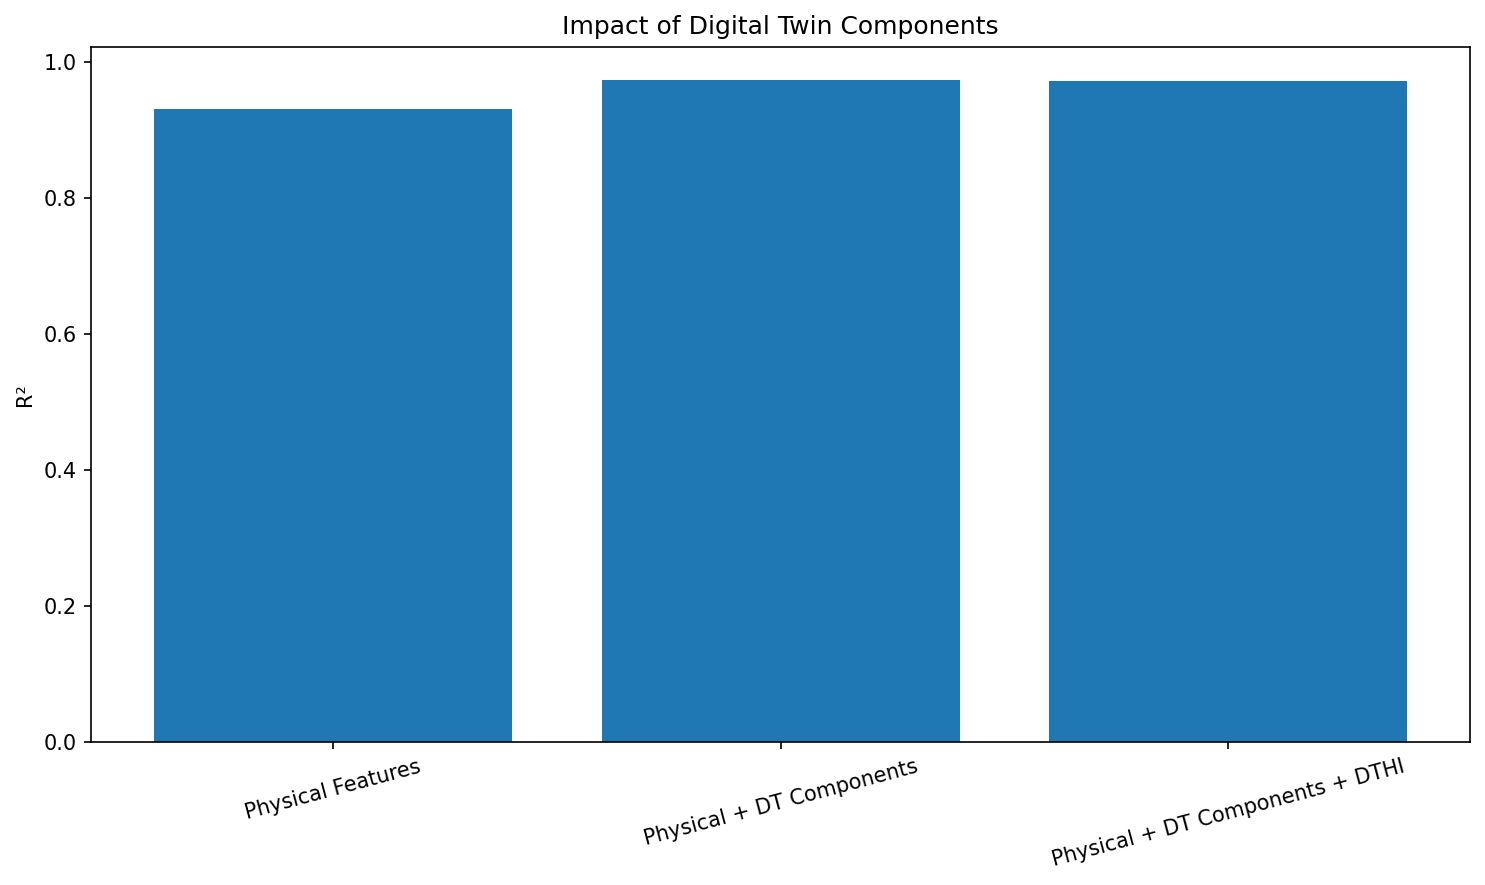

In [51]:
plt.figure(figsize=(10,6))

plt.bar(

    ablation_results['Configuration'],

    ablation_results['R2']

)

plt.ylabel("R²")

plt.title(
    "Impact of Digital Twin Components"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/Figure_28_DT_Ablation_Analysis.tiff",

    dpi=600,

    format='tiff'

)

plt.show()

In [52]:
import os

files = [

"Figure_21_Feature_Importance.tiff",

"Figure_22_SHAP_Summary.tiff",

"Figure_23_SHAP_Dependence.tiff",

"Figure_24_SHAP_Waterfall.tiff",

"Figure_28_DT_Ablation_Analysis.tiff"

]

for f in files:

    print(
        f,
        os.path.exists(
            f"{RESULT_DIR}/{f}"
        )
    )

Figure_21_Feature_Importance.tiff True
Figure_22_SHAP_Summary.tiff True
Figure_23_SHAP_Dependence.tiff True
Figure_24_SHAP_Waterfall.tiff True
Figure_28_DT_Ablation_Analysis.tiff True


In [53]:
proposed_framework = pd.DataFrame({

'Stage':[

'Input Layer',

'Preprocessing Layer',

'Physical Feature Extraction',

'Digital Twin Modeling',

'Feature Fusion',

'Prediction Engine',

'Explainability Layer',

'Output Layer'

],

'Description':[

'NASA Battery Dataset (B0005, B0006, B0007, B0018)',

'Data cleaning, SOH and RUL computation',

'AvgVoltage, MaxVoltage, AvgCurrent, AvgTemp, Duration, Cycle',

'DI, TSI, VHI, TGI, VSI',

'Fusion of physical and Digital Twin descriptors',

'DTEC-Net (CatBoost Regressor)',

'SHAP Explainability Analysis',

'SOH Prediction'

]

})

proposed_framework.to_csv(

    f"{RESULT_DIR}/Table_07_Proposed_DTEC_Net_Framework.csv",

    index=False

)

proposed_framework

,Stage,Description
0,Input Layer,"NASA Battery Dataset (B0005, B0006, B0007, B0018)"
1,Preprocessing Layer,"Data cleaning, SOH and RUL computation"
2,Physical Feature Extraction,"AvgVoltage, MaxVoltage, AvgCurrent, AvgTemp, D..."
3,Digital Twin Modeling,"DI, TSI, VHI, TGI, VSI"
4,Feature Fusion,Fusion of physical and Digital Twin descriptors
5,Prediction Engine,DTEC-Net (CatBoost Regressor)
6,Explainability Layer,SHAP Explainability Analysis
7,Output Layer,SOH Prediction


In [54]:
digital_twin_table = pd.DataFrame({

'Component':[

'DI',

'TSI',

'VHI',

'TGI',

'VSI'

],

'Full_Name':[

'Degradation Index',

'Thermal Stress Index',

'Voltage Health Index',

'Temperature Gradient Index',

'Voltage Stability Index'

],

'Purpose':[

'Capacity degradation monitoring',

'Thermal condition assessment',

'Voltage health characterization',

'Thermal fluctuation tracking',

'Voltage consistency evaluation'

]

})

digital_twin_table.to_csv(

    f"{RESULT_DIR}/Table_08_Digital_Twin_Components.csv",

    index=False

)

digital_twin_table

,Component,Full_Name,Purpose
0,DI,Degradation Index,Capacity degradation monitoring
1,TSI,Thermal Stress Index,Thermal condition assessment
2,VHI,Voltage Health Index,Voltage health characterization
3,TGI,Temperature Gradient Index,Thermal fluctuation tracking
4,VSI,Voltage Stability Index,Voltage consistency evaluation


In [55]:
contribution_table = pd.DataFrame({

'Contribution_No':[1,2,3,4,5],

'Contribution':[

'Development of Digital Twin degradation descriptors',

'Integration of Digital Twin features with CatBoost',

'Cross-battery SOH prediction framework',

'SHAP-based explainability',

'Comprehensive ablation study'

]

})

contribution_table.to_csv(

    f"{RESULT_DIR}/Table_09_DTEC_Net_Contributions.csv",

    index=False

)

contribution_table

,Contribution_No,Contribution
0,1,Development of Digital Twin degradation descri...
1,2,Integration of Digital Twin features with CatB...
2,3,Cross-battery SOH prediction framework
3,4,SHAP-based explainability
4,5,Comprehensive ablation study


In [56]:
import os

tables = sorted(

    [

        f for f in os.listdir(
            RESULT_DIR
        )

        if f.endswith('.csv')

    ]

)

for t in tables:

    print(t)

Feature_Correlation_with_SOH.csv
Table_05_Feature_Importance.csv
Table_06_Ablation_Study.csv
Table_07_Proposed_DTEC_Net_Framework.csv
Table_08_Digital_Twin_Components.csv
Table_09_DTEC_Net_Contributions.csv
Table_10_DT_Model_Comparison.csv
Table_Feature_Set_Comparison.csv


In [57]:
figures = sorted(

    [

        f for f in os.listdir(
            RESULT_DIR
        )

        if f.endswith('.tiff')

    ]

)

for f in figures:

    print(f)

Figure_01_Capacity_Degradation.tiff
Figure_02_SOH_Degradation.tiff
Figure_03_RUL_Evolution.tiff
Figure_04_Correlation_Matrix.tiff
Figure_05_DTHI_Evolution.tiff
Figure_07_SOH_vs_DTHI.tiff
Figure_10_Health_State_Distribution.tiff
Figure_11_Feature_Correlation_SOH.tiff
Figure_21_Feature_Importance.tiff
Figure_22_SHAP_Summary.tiff
Figure_23_SHAP_Dependence.tiff
Figure_24_SHAP_Waterfall.tiff
Figure_28_DT_Ablation_Analysis.tiff
Figure_29_DT_Model_Comparison.tiff
Figure_30_DT_Model_RMSE.tiff


In [58]:
import shutil

ZIP_NAME = "/kaggle/working/DTEC_Net_SCI_Final"

shutil.make_archive(

    ZIP_NAME,

    'zip',

    RESULT_DIR

)

print(
    "ZIP Created Successfully"
)

print(
    ZIP_NAME + ".zip"
)

ZIP Created Successfully
/kaggle/working/DTEC_Net_SCI_Final.zip


In [59]:
import os

print(

    os.path.exists(

        "/kaggle/working/DTEC_Net_SCI_Final.zip"

    )

)

True
